# Assignment 03 - Field EDA

This notebook analyzes New Mexico field-level crop and soil datasets (2008-2020).

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

In [2]:
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root from current working directory")

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data"

soil_path = DATA_DIR / "soil" / "nm_soil_data.csv"
crop_path = DATA_DIR / "crops" / "nm_cdl_2008_2020.csv"
fields_path = DATA_DIR / "boundaries" / "nm_top_200_fields.geojson"

soil_path, crop_path, fields_path
FIGURES_DIR = PROJECT_ROOT / "notebooks" / "03_field_eda" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Figures directory: {FIGURES_DIR}")

Project root: /workspaces/EVTLR-Project
Figures directory: /workspaces/EVTLR-Project/notebooks/03_field_eda/figures


In [3]:
soil_df = pd.read_csv(soil_path)
crop_df = pd.read_csv(crop_path)

with open(fields_path, "r", encoding="utf-8") as f:
    fields_geojson = json.load(f)

fields_records = [feature.get("properties", {}) for feature in fields_geojson.get("features", [])]
fields_df = pd.DataFrame(fields_records)

print(f"soil_df shape: {soil_df.shape}")
print(f"crop_df shape: {crop_df.shape}")
print(f"fields_df shape: {fields_df.shape}")

soil_df shape: (3945, 16)
crop_df shape: (2587, 6)
fields_df shape: (199, 4)


In [4]:
def inspect_dataframe(df: pd.DataFrame, name: str) -> None:
    print("=" * 100)
    print(f"{name} - .info()")
    print("=" * 100)
    df.info()
    print()

    print("=" * 100)
    print(f"{name} - .describe(include='all').T")
    print("=" * 100)
    display(df.describe(include="all").T)

inspect_dataframe(soil_df, "Soil data (horizon-level)")
inspect_dataframe(crop_df, "Crop data (field-year)")
inspect_dataframe(fields_df, "Field boundaries properties")

Soil data (horizon-level) - .info()
<class 'pandas.DataFrame'>
RangeIndex: 3945 entries, 0 to 3944
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mukey         3945 non-null   int64  
 1   muname        3945 non-null   str    
 2   compname      3945 non-null   str    
 3   comppct_r     3945 non-null   int64  
 4   drainagecl    3938 non-null   str    
 5   hzdept_r      3908 non-null   float64
 6   hzdepb_r      3908 non-null   float64
 7   om_r          3714 non-null   float64
 8   ph1to1h2o_r   3775 non-null   float64
 9   awc_r         3777 non-null   float64
 10  claytotal_r   3775 non-null   float64
 11  sandtotal_r   3350 non-null   float64
 12  silttotal_r   3350 non-null   float64
 13  dbthirdbar_r  3717 non-null   float64
 14  cec7_r        3775 non-null   float64
 15  field_id      3945 non-null   str    
dtypes: float64(10), int64(2), str(4)
memory usage: 778.0 KB

Soil data (horizon-level) - .des

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
mukey,3945.0,NaN,NaN,NaN,825860.190368,684771.5043,376394.0,376434.0,376474.0,1547772.0,2606831.0
muname,3945,135,"Kimbrough-Lea complex, dry, 0 to 3 percent slopes",385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
compname,3945,102,Kimbrough,309,NaN,NaN,NaN,NaN,NaN,NaN,NaN
comppct_r,3945.0,NaN,NaN,NaN,24.788847,29.83215,1.0,5.0,7.0,45.0,100.0
drainagecl,3938,5,Well drained,3675,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hzdept_r,3908.0,NaN,NaN,NaN,8.221085,9.942695,0.0,0.0,0.0,17.0,29.0
hzdepb_r,3908.0,NaN,NaN,NaN,42.625896,35.32959,3.0,20.0,30.0,54.25,203.0
om_r,3714.0,NaN,NaN,NaN,1.062593,0.846795,0.05,0.5,0.75,1.4,3.9
ph1to1h2o_r,3775.0,NaN,NaN,NaN,7.670861,0.440328,6.5,7.3,7.7,8.0,8.9
awc_r,3777.0,NaN,NaN,NaN,0.126402,0.033994,0.0,0.12,0.13,0.15,0.2


Crop data (field-year) - .info()
<class 'pandas.DataFrame'>
RangeIndex: 2587 entries, 0 to 2586
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   field_id      2587 non-null   str    
 1   year          2587 non-null   int64  
 2   crop_code     2587 non-null   int64  
 3   crop_name     2587 non-null   str    
 4   dominant_pct  2587 non-null   float64
 5   total_pixels  2587 non-null   int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 185.4 KB

Crop data (field-year) - .describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
field_id,2587,199,NM_FIELD_001,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,2587.0,NaN,NaN,NaN,2014.0,3.742381,2008.0,2011.0,2014.0,2017.0,2020.0
crop_code,2587.0,NaN,NaN,NaN,144.117124,50.325889,1.0,152.0,152.0,176.0,236.0
crop_name,2587,17,Grassland/Pasture,1144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dominant_pct,2587.0,NaN,NaN,NaN,87.279552,18.864028,19.8,81.55,97.5,100.0,100.0
total_pixels,2587.0,NaN,NaN,NaN,259.899497,186.482395,21.0,106.0,212.0,367.0,856.0


Field boundaries properties - .info()
<class 'pandas.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   field_id     199 non-null    str    
 1   county       199 non-null    str    
 2   county_fips  199 non-null    str    
 3   area_acres   199 non-null    float64
dtypes: float64(1), str(3)
memory usage: 10.3 KB

Field boundaries properties - .describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
field_id,199,199,NM_FIELD_001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
county,199,3,Lea,106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
county_fips,199,3,025,106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area_acres,199.0,NaN,NaN,NaN,560.595969,403.777943,38.334832,229.378072,454.751185,776.451273,1856.477282


In [5]:
soil_numeric_cols = [
    "comppct_r",
    "hzdept_r",
    "hzdepb_r",
    "om_r",
    "ph1to1h2o_r",
    "awc_r",
    "claytotal_r",
    "sandtotal_r",
    "silttotal_r",
    "dbthirdbar_r",
    "cec7_r",
]

for col in soil_numeric_cols:
    soil_df[col] = pd.to_numeric(soil_df[col], errors="coerce")

primary_soil = (
    soil_df.sort_values(["field_id", "comppct_r"], ascending=[True, False])
    .drop_duplicates(subset=["field_id"])
    [["field_id", "compname", "drainagecl", "muname", "mukey"]]
    .rename(
        columns={
            "compname": "soil_type",
            "drainagecl": "drainage_class",
            "muname": "map_unit_name",
        }
    )
)

soil_field_stats = soil_df.groupby("field_id", as_index=False)[soil_numeric_cols].mean()
soil_field_stats = soil_field_stats.rename(columns={c: f"{c}_field_avg" for c in soil_numeric_cols})

soil_field_df = primary_soil.merge(soil_field_stats, on="field_id", how="left")

fields_keep = fields_df[["field_id", "county", "county_fips", "area_acres"]].copy()
merged_df = (
    crop_df.merge(fields_keep, on="field_id", how="left")
    .merge(soil_field_df, on="field_id", how="left")
)
merged_df["estimated_crop_acres"] = merged_df["area_acres"] * (merged_df["dominant_pct"] / 100.0)

print(f"soil_field_df shape: {soil_field_df.shape}")
print(f"merged_df shape: {merged_df.shape}")
merged_df.head()

soil_field_df shape: (199, 16)
merged_df shape: (2587, 25)


,field_id,year,crop_code,crop_name,dominant_pct,total_pixels,county,county_fips,area_acres,soil_type,drainage_class,map_unit_name,mukey,comppct_r_field_avg,hzdept_r_field_avg,hzdepb_r_field_avg,om_r_field_avg,ph1to1h2o_r_field_avg,awc_r_field_avg,claytotal_r_field_avg,sandtotal_r_field_avg,silttotal_r_field_avg,dbthirdbar_r_field_avg,cec7_r_field_avg,estimated_crop_acres
0,NM_FIELD_001,2008,176,Grassland/Pasture,94.7,856,Roosevelt,041,1856.477282,Kimberson,Well drained,"Kimberson gravelly loam, 0 to 3 percent slopes",1547903,26.757576,8.818182,43.272727,1.572812,7.925000,0.136250,20.096875,56.587500,23.315625,1.450937,15.150000,1758.083986
1,NM_FIELD_002,2008,152,Shrubland,100.0,842,Lea,025,1795.676593,Tonuco,Excessively drained,"Tonuco loamy fine sand, 0 to 3 percent slopes",376479,23.294118,7.235294,57.470588,0.496667,7.500000,0.102353,13.470588,78.040000,9.560000,1.465294,7.794118,1795.676593
2,NM_FIELD_003,2008,152,Shrubland,88.7,829,Roosevelt,041,1795.488384,Amarose,Well drained,"Amarose loamy fine sand, 0 to 3 percent slopes",1547772,24.538462,8.948718,41.717949,0.765641,7.428205,0.109744,12.274359,78.130769,9.594872,1.508974,7.333333,1592.598196
3,NM_FIELD_004,2008,4,Sorghum,62.8,758,Roosevelt,041,1639.508575,Amarillo,Well drained,"Amarillo fine sandy loam, 0 to 1 percent slopes",1547757,26.131579,10.131579,43.157895,0.990526,7.886842,0.140526,26.368421,55.468421,18.163158,1.439211,17.965789,1029.611385
4,NM_FIELD_005,2008,176,Grassland/Pasture,100.0,724,Roosevelt,041,1588.144303,Arizer,Well drained,"Arizer sandy clay loam, 1 to 3 percent slopes",1547781,27.145455,9.236364,39.654545,1.214600,7.900000,0.127059,21.256000,52.952000,25.792000,1.442200,13.776000,1588.144303


In [6]:
inspect_dataframe(soil_field_df, "Soil data (field-level aggregates)")
inspect_dataframe(merged_df, "Merged crop + field + soil data")

Soil data (field-level aggregates) - .info()
<class 'pandas.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   field_id                199 non-null    str    
 1   soil_type               199 non-null    str    
 2   drainage_class          198 non-null    str    
 3   map_unit_name           199 non-null    str    
 4   mukey                   199 non-null    int64  
 5   comppct_r_field_avg     199 non-null    float64
 6   hzdept_r_field_avg      199 non-null    float64
 7   hzdepb_r_field_avg      199 non-null    float64
 8   om_r_field_avg          199 non-null    float64
 9   ph1to1h2o_r_field_avg   199 non-null    float64
 10  awc_r_field_avg         199 non-null    float64
 11  claytotal_r_field_avg   199 non-null    float64
 12  sandtotal_r_field_avg   199 non-null    float64
 13  silttotal_r_field_avg   199 non-null    float64
 14  dbthirdb

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
field_id,199,199,NM_FIELD_001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
soil_type,199,42,Kimbrough,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
drainage_class,198,3,Well drained,172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
map_unit_name,199,65,"Amarillo fine sandy loam, 0 to 1 percent slopes",16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mukey,199.0,NaN,NaN,NaN,758586.261307,596141.223159,376399.0,376432.5,376475.0,1547759.0,2520113.0
comppct_r_field_avg,199.0,NaN,NaN,NaN,24.721515,3.436793,16.428571,22.272727,24.9,26.893357,38.4
hzdept_r_field_avg,199.0,NaN,NaN,NaN,7.87382,1.883584,0.0,6.857143,8.266667,8.974359,12.125
hzdepb_r_field_avg,199.0,NaN,NaN,NaN,44.258703,11.76258,26.75,37.25641,41.717949,46.554627,77.25
om_r_field_avg,199.0,NaN,NaN,NaN,1.015305,0.479689,0.235714,0.654512,1.009231,1.354796,2.078571
ph1to1h2o_r_field_avg,199.0,NaN,NaN,NaN,7.636424,0.186929,7.128571,7.5,7.6,7.750926,8.19


Merged crop + field + soil data - .info()
<class 'pandas.DataFrame'>
RangeIndex: 2587 entries, 0 to 2586
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   field_id                2587 non-null   str    
 1   year                    2587 non-null   int64  
 2   crop_code               2587 non-null   int64  
 3   crop_name               2587 non-null   str    
 4   dominant_pct            2587 non-null   float64
 5   total_pixels            2587 non-null   int64  
 6   county                  2587 non-null   str    
 7   county_fips             2587 non-null   str    
 8   area_acres              2587 non-null   float64
 9   soil_type               2587 non-null   str    
 10  drainage_class          2574 non-null   str    
 11  map_unit_name           2587 non-null   str    
 12  mukey                   2587 non-null   int64  
 13  comppct_r_field_avg     2587 non-null   float64
 14  hzdept_r_

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
field_id,2587,199,NM_FIELD_001,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,2587.0,NaN,NaN,NaN,2014.0,3.742381,2008.0,2011.0,2014.0,2017.0,2020.0
crop_code,2587.0,NaN,NaN,NaN,144.117124,50.325889,1.0,152.0,152.0,176.0,236.0
crop_name,2587,17,Grassland/Pasture,1144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dominant_pct,2587.0,NaN,NaN,NaN,87.279552,18.864028,19.8,81.55,97.5,100.0,100.0
total_pixels,2587.0,NaN,NaN,NaN,259.899497,186.482395,21.0,106.0,212.0,367.0,856.0
county,2587,3,Lea,1378,NaN,NaN,NaN,NaN,NaN,NaN,NaN
county_fips,2587,3,025,1378,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area_acres,2587.0,NaN,NaN,NaN,560.595969,402.840014,38.334832,228.510382,454.751185,784.988937,1856.477282
soil_type,2587,42,Kimbrough,429,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Year-Specific Dashboard Visuals (2010 and 2020)

The following charts are filtered to exclude `Other Hay/Non Alfalfa`, `Code_236` (crop code 236), and `Developed/Medium Intensity`. They are exported as high-resolution assets for a standalone dashboard.

In [7]:
EXCLUDED_CROP_NAMES = {"Other Hay/Non Alfalfa", "Developed/Medium Intensity"}
EXCLUDED_CROP_CODES = {236}
TARGET_YEARS = [2010, 2020]

OUTPUT_DIR = PROJECT_ROOT / "output"
DASHBOARD_ASSETS_DIR = OUTPUT_DIR / "dashboard_assets"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DASHBOARD_ASSETS_DIR.mkdir(parents=True, exist_ok=True)

dashboard_df = merged_df[~merged_df["crop_name"].isin(EXCLUDED_CROP_NAMES)].copy()
dashboard_df = dashboard_df[~dashboard_df["crop_code"].isin(EXCLUDED_CROP_CODES)].copy()
dashboard_df = dashboard_df[dashboard_df["year"].isin(TARGET_YEARS)].copy()

dashboard_df["crop_name"] = dashboard_df["crop_name"].astype(str)
dashboard_df["soil_type"] = dashboard_df["soil_type"].fillna("Unknown Soil")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 320

print(f"Dashboard assets directory: {DASHBOARD_ASSETS_DIR}")
print(f"Filtered rows for dashboard charts: {len(dashboard_df)}")
dashboard_df[["year", "crop_code", "crop_name"]].drop_duplicates().sort_values(["year", "crop_code"]).head(20)

Dashboard assets directory: /workspaces/EVTLR-Project/output/dashboard_assets
Filtered rows for dashboard charts: 397


,year,crop_code,crop_name
547,2010,2,Cotton
462,2010,4,Sorghum
401,2010,24,Winter Wheat
438,2010,36,Alfalfa
429,2010,61,Fallow/Idle Cropland
425,2010,122,Developed/Low Intensity
399,2010,152,Shrubland
398,2010,176,Grassland/Pasture
2452,2020,1,Corn
2537,2020,2,Cotton


/tmp/ipykernel_35483/999467904.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=acreage_2010, x="estimated_crop_acres", y="crop_name", palette="crest")


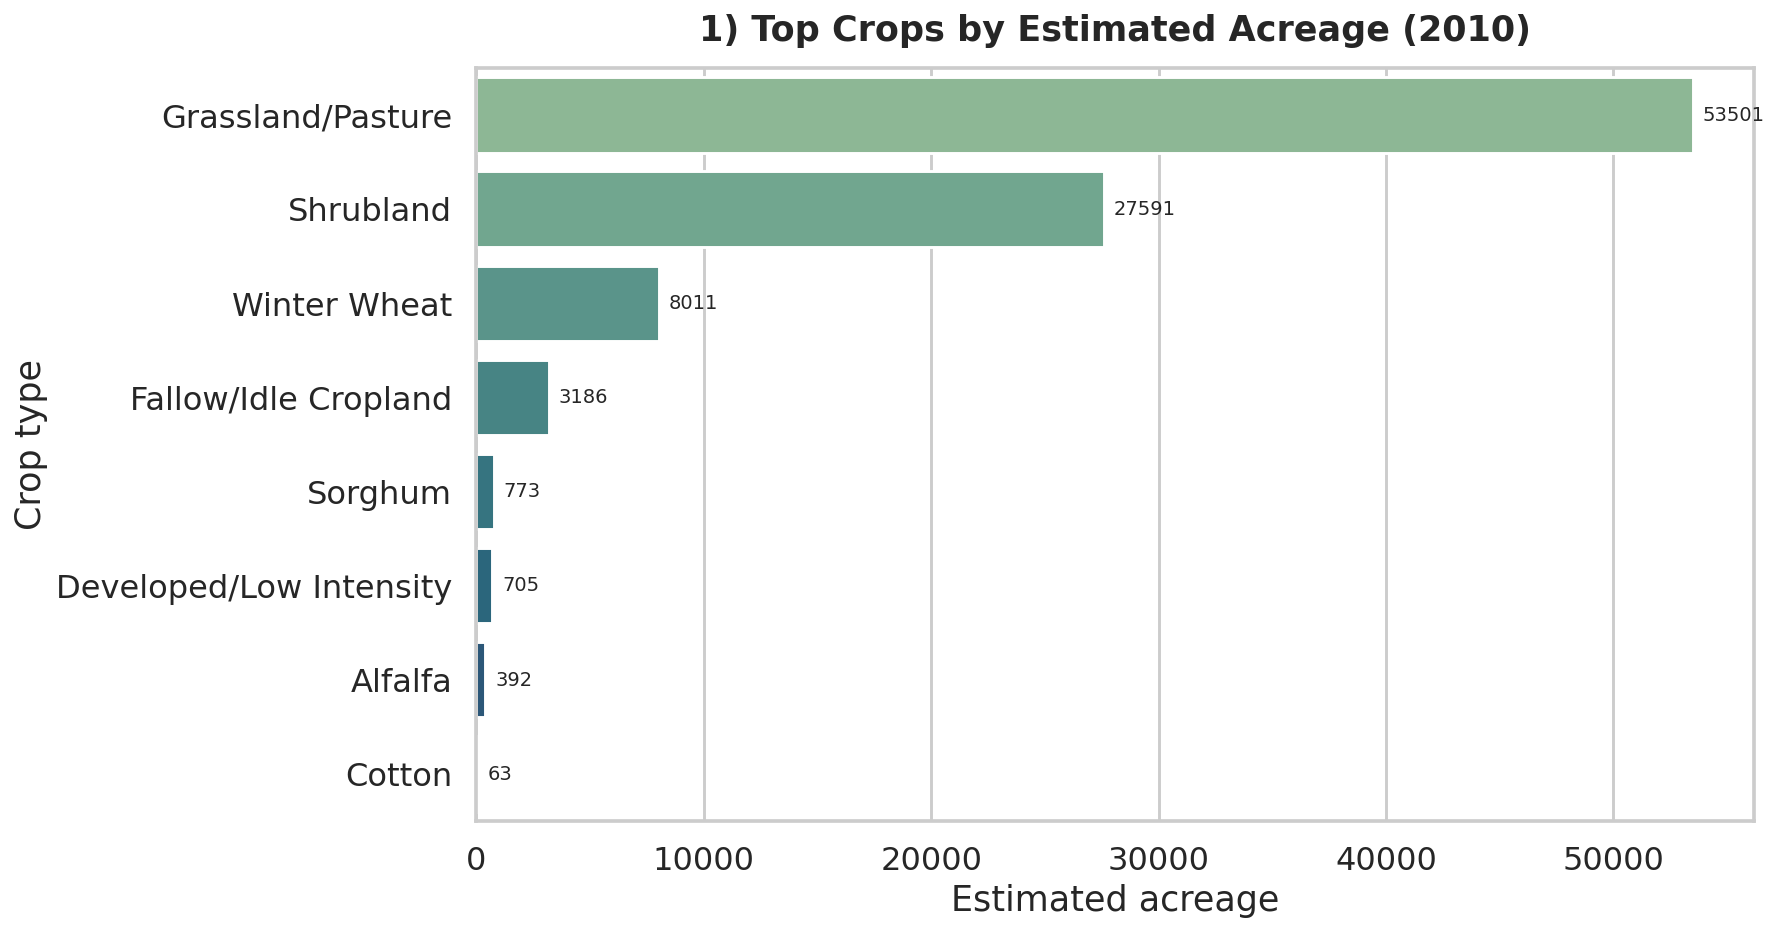

In [8]:
year_df = dashboard_df[dashboard_df["year"] == 2010].copy()
acreage_2010 = (
    year_df.groupby("crop_name", as_index=False)["estimated_crop_acres"]
    .sum()
    .sort_values("estimated_crop_acres", ascending=False)
)

plt.figure(figsize=(13, 7))
ax = sns.barplot(data=acreage_2010, x="estimated_crop_acres", y="crop_name", palette="crest")
ax.set_title("1) Top Crops by Estimated Acreage (2010)", pad=14, weight="bold")
ax.set_xlabel("Estimated acreage")
ax.set_ylabel("Crop type")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=10, padding=5)
plt.tight_layout()
plt.savefig(DASHBOARD_ASSETS_DIR / "01_crop_total_estimated_area_2010.png", bbox_inches="tight")
plt.show()

**Interpretation - 2010 crop acreage**

This chart ranks crop classes by estimated occupied acreage in 2010. In this year, land use is heavily concentrated in grassland/pasture and shrubland, while annual crops like winter wheat and sorghum occupy much smaller shares.

/tmp/ipykernel_35483/1933991538.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=acreage_2020, x="estimated_crop_acres", y="crop_name", palette="mako")


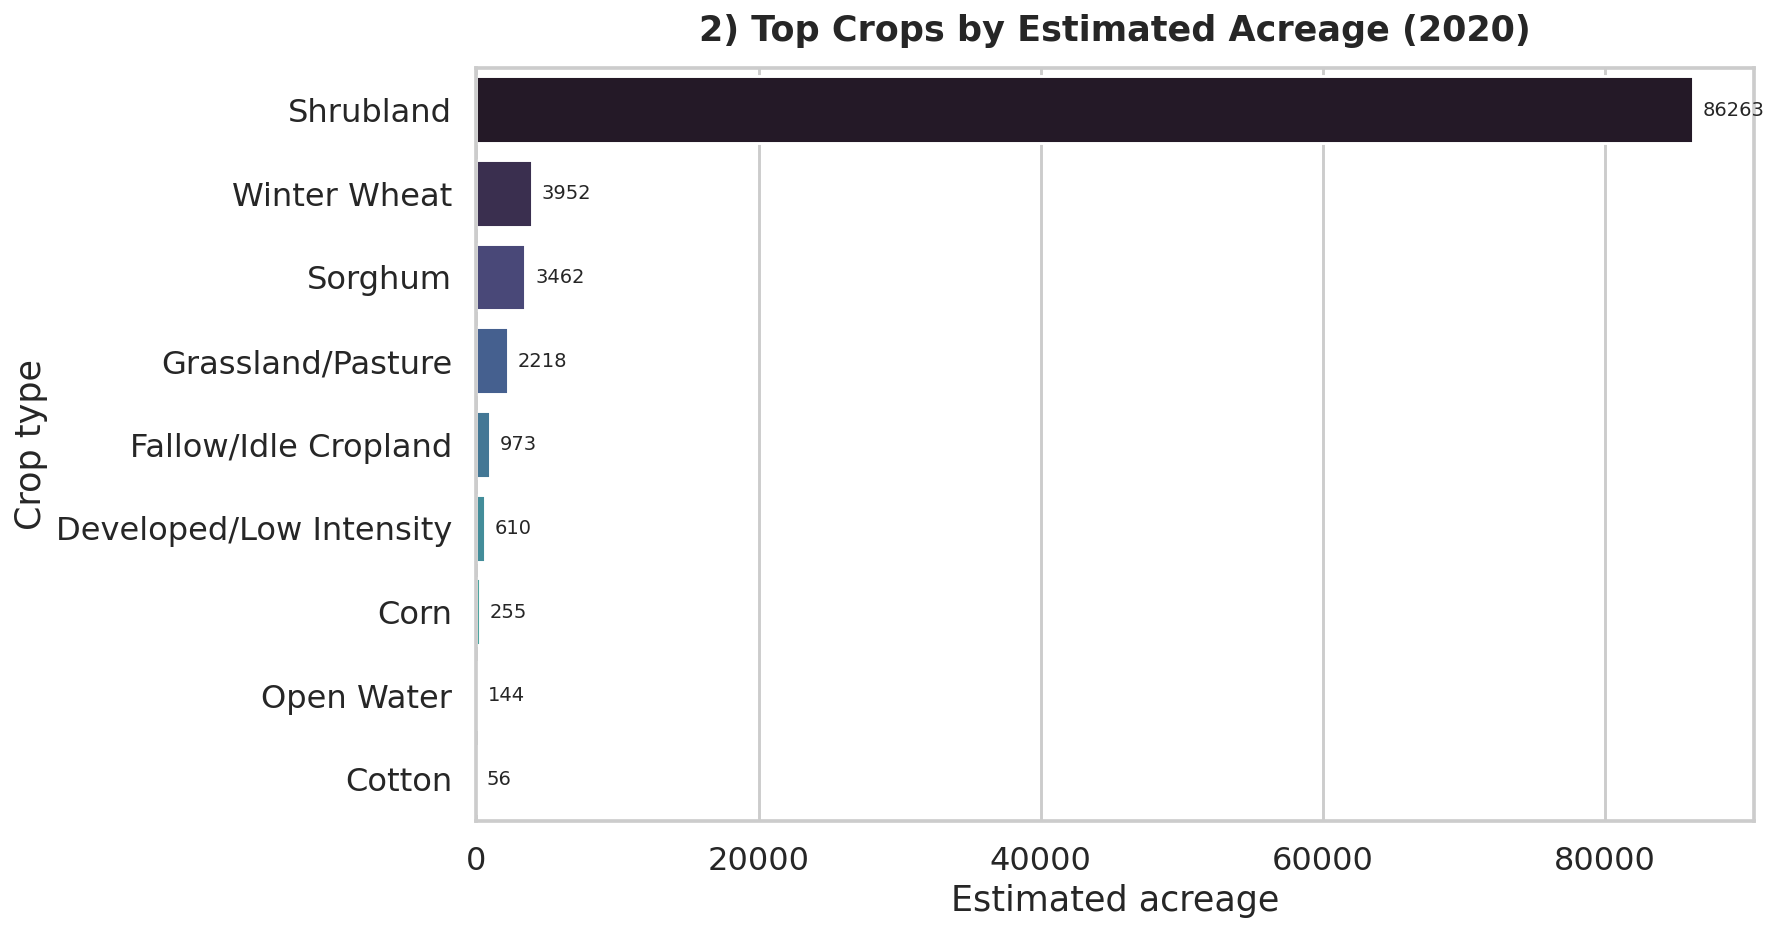

In [9]:
year_df = dashboard_df[dashboard_df["year"] == 2020].copy()
acreage_2020 = (
    year_df.groupby("crop_name", as_index=False)["estimated_crop_acres"]
    .sum()
    .sort_values("estimated_crop_acres", ascending=False)
)

plt.figure(figsize=(13, 7))
ax = sns.barplot(data=acreage_2020, x="estimated_crop_acres", y="crop_name", palette="mako")
ax.set_title("2) Top Crops by Estimated Acreage (2020)", pad=14, weight="bold")
ax.set_xlabel("Estimated acreage")
ax.set_ylabel("Crop type")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=10, padding=5)
plt.tight_layout()
plt.savefig(DASHBOARD_ASSETS_DIR / "02_crop_total_estimated_area_2020.png", bbox_inches="tight")
plt.show()

**Interpretation - 2020 crop acreage**

The 2020 distribution can be compared directly with 2010 to spot shifts in dominant land cover classes. The ordering remains concentrated in a few major classes, with only a small tail of minor crop categories.

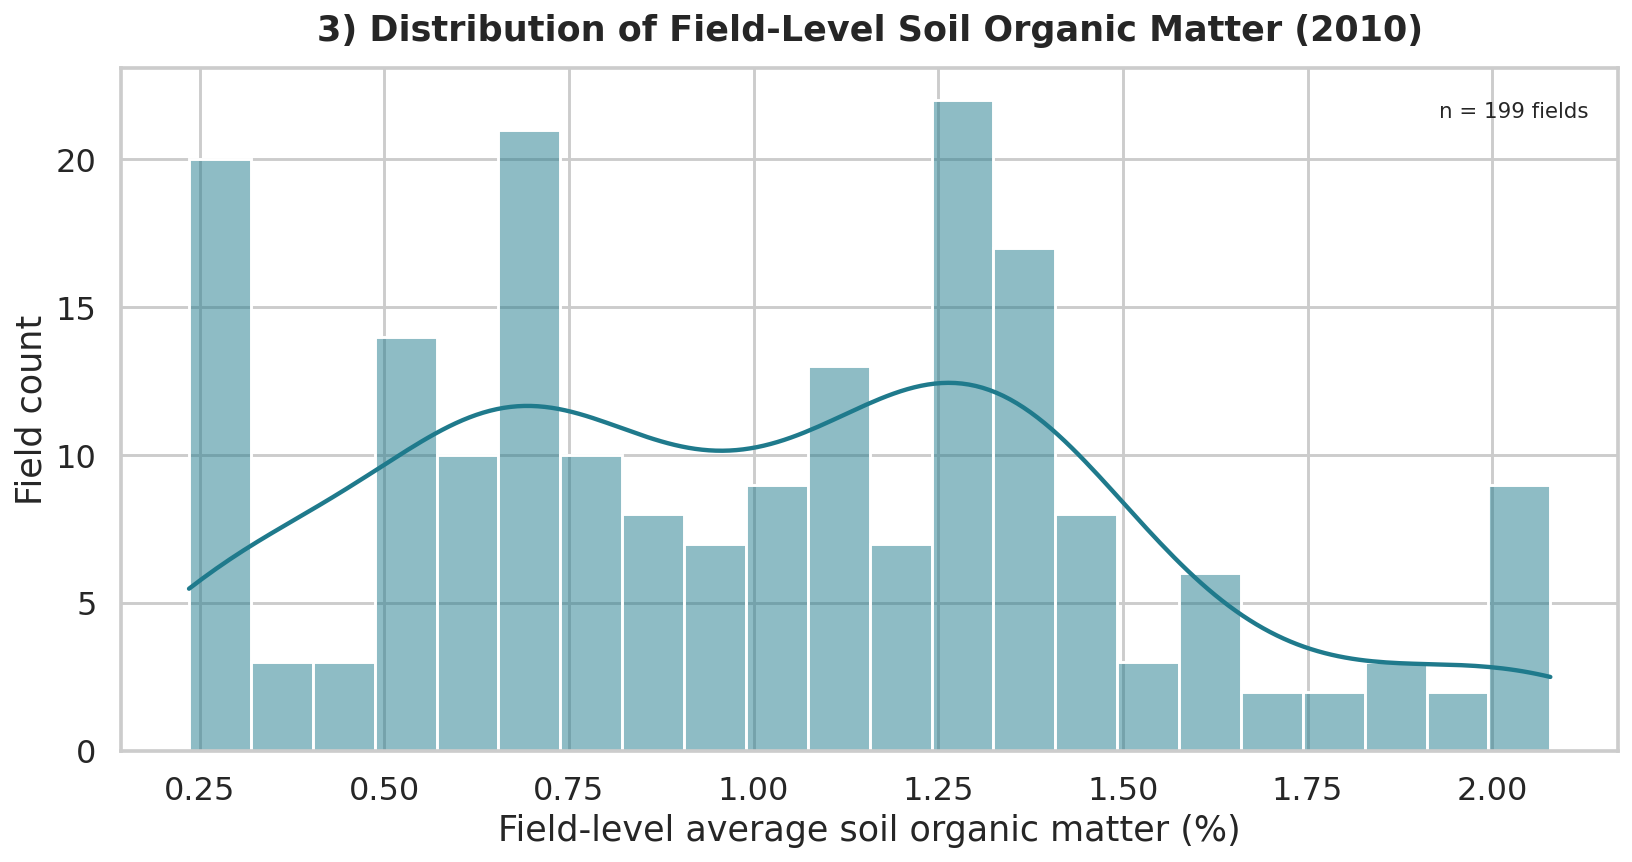

In [10]:
year_df = dashboard_df[dashboard_df["year"] == 2010].copy()
om_2010 = year_df[["field_id", "om_r_field_avg"]].dropna().drop_duplicates(subset=["field_id"])

plt.figure(figsize=(12, 6.5))
ax = sns.histplot(om_2010["om_r_field_avg"], bins=22, kde=True, color="#1f7a8c")
ax.set_title("3) Distribution of Field-Level Soil Organic Matter (2010)", pad=14, weight="bold")
ax.set_xlabel("Field-level average soil organic matter (%)")
ax.set_ylabel("Field count")
ax.text(0.98, 0.95, f"n = {len(om_2010)} fields", ha="right", va="top", transform=ax.transAxes, fontsize=11)
plt.tight_layout()
plt.savefig(DASHBOARD_ASSETS_DIR / "03_soil_organic_matter_distribution_2010.png", bbox_inches="tight")
plt.show()

**Interpretation - 2010 OM distribution**

This histogram shows how field-level organic matter values are distributed among fields observed in 2010. The center and spread indicate typical OM conditions and variability across the study area.

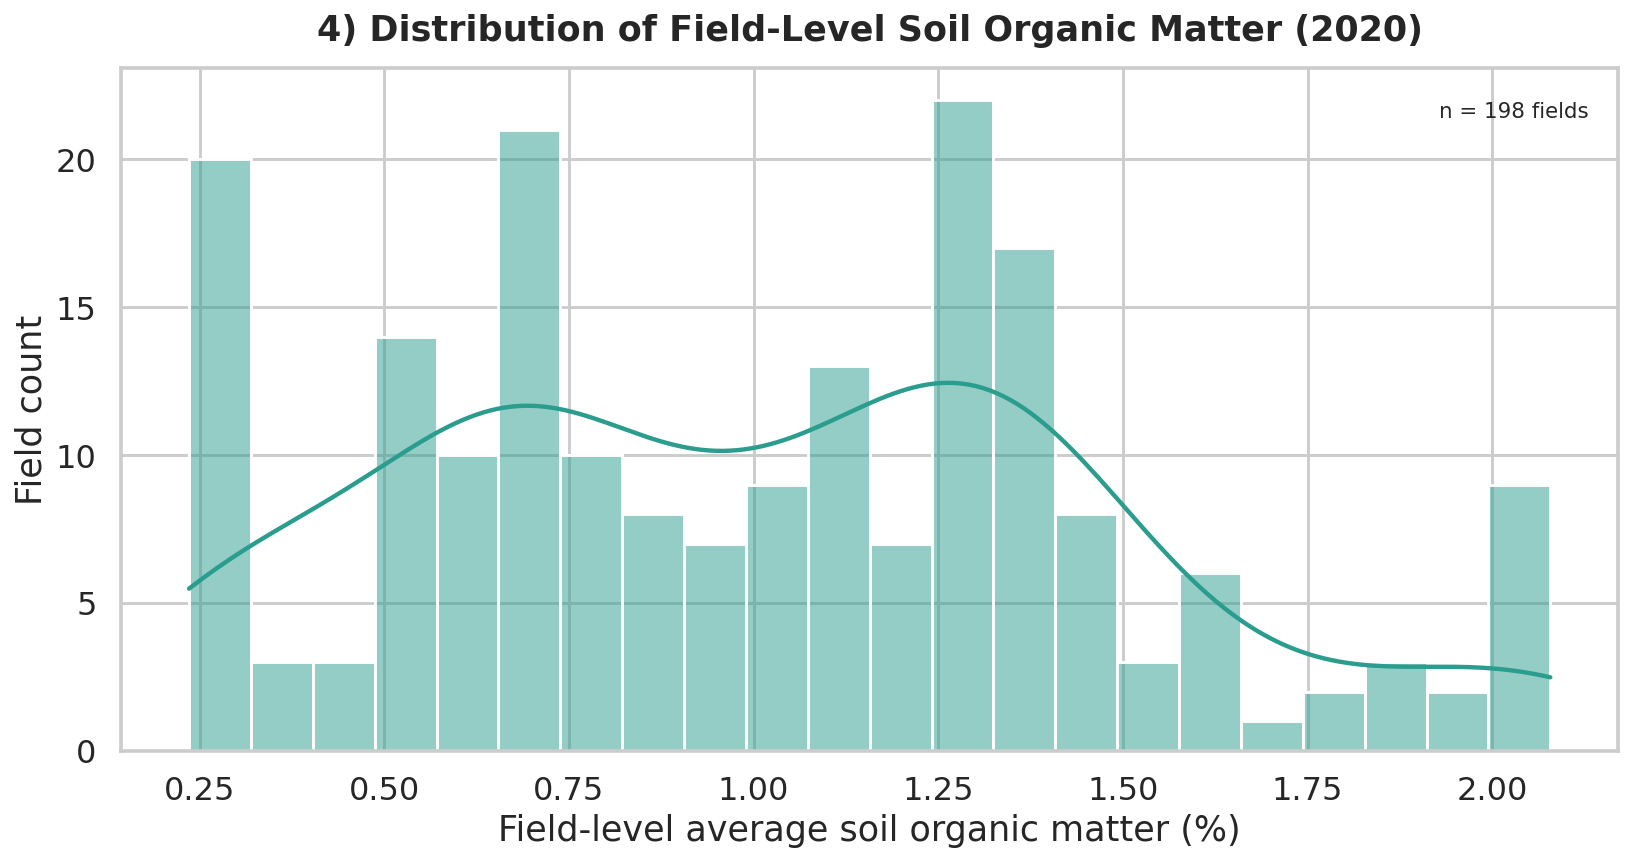

In [11]:
year_df = dashboard_df[dashboard_df["year"] == 2020].copy()
om_2020 = year_df[["field_id", "om_r_field_avg"]].dropna().drop_duplicates(subset=["field_id"])

plt.figure(figsize=(12, 6.5))
ax = sns.histplot(om_2020["om_r_field_avg"], bins=22, kde=True, color="#2a9d8f")
ax.set_title("4) Distribution of Field-Level Soil Organic Matter (2020)", pad=14, weight="bold")
ax.set_xlabel("Field-level average soil organic matter (%)")
ax.set_ylabel("Field count")
ax.text(0.98, 0.95, f"n = {len(om_2020)} fields", ha="right", va="top", transform=ax.transAxes, fontsize=11)
plt.tight_layout()
plt.savefig(DASHBOARD_ASSETS_DIR / "04_soil_organic_matter_distribution_2020.png", bbox_inches="tight")
plt.show()

**Interpretation - 2020 OM distribution**

This distribution supports side-by-side comparison against 2010. Any visible shift in peak location or tail thickness may indicate a change in the mix of field conditions represented in the 2020 crop-year subset.

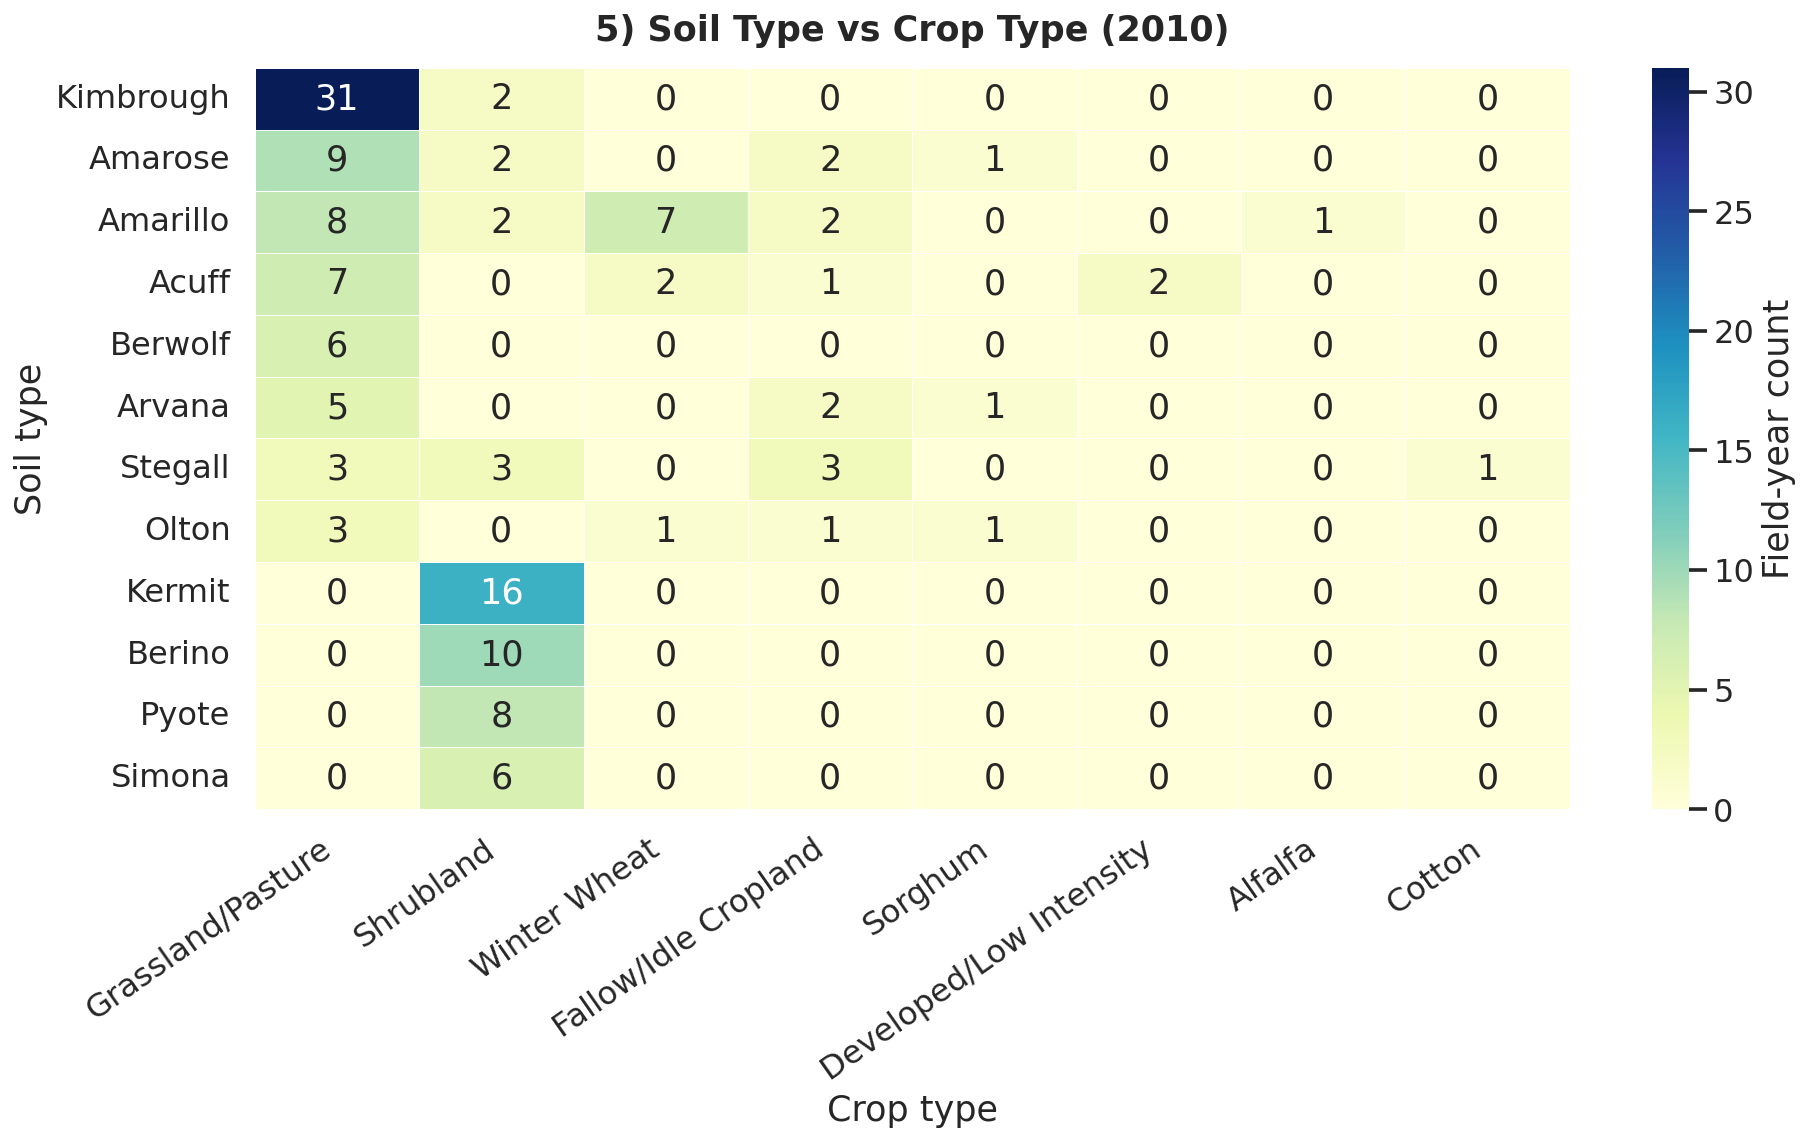

In [12]:
year_df = dashboard_df[dashboard_df["year"] == 2010].copy()
top_soils_2010 = year_df["soil_type"].value_counts().head(12).index
top_crops_2010 = year_df["crop_name"].value_counts().head(10).index

ct_2010 = pd.crosstab(
    year_df[year_df["soil_type"].isin(top_soils_2010)]["soil_type"],
    year_df[year_df["soil_type"].isin(top_soils_2010)]["crop_name"],
)
ct_2010 = ct_2010.reindex(columns=[c for c in top_crops_2010 if c in ct_2010.columns], fill_value=0)
ct_2010 = ct_2010.sort_values(by=ct_2010.columns.tolist(), ascending=False)

plt.figure(figsize=(14, 8.5))
ax = sns.heatmap(ct_2010, cmap="YlGnBu", annot=True, fmt="d", linewidths=0.35, cbar_kws={"label": "Field-year count"})
ax.set_title("5) Soil Type vs Crop Type (2010)", pad=14, weight="bold")
ax.set_xlabel("Crop type")
ax.set_ylabel("Soil type")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(DASHBOARD_ASSETS_DIR / "05_soil_type_vs_crop_type_2010.png", bbox_inches="tight")
plt.show()

**Interpretation - 2010 soil type vs crop type**

Darker cells and larger annotations identify frequent soil-crop combinations in 2010. This helps reveal which crops are most associated with the dominant soil classes during that year.

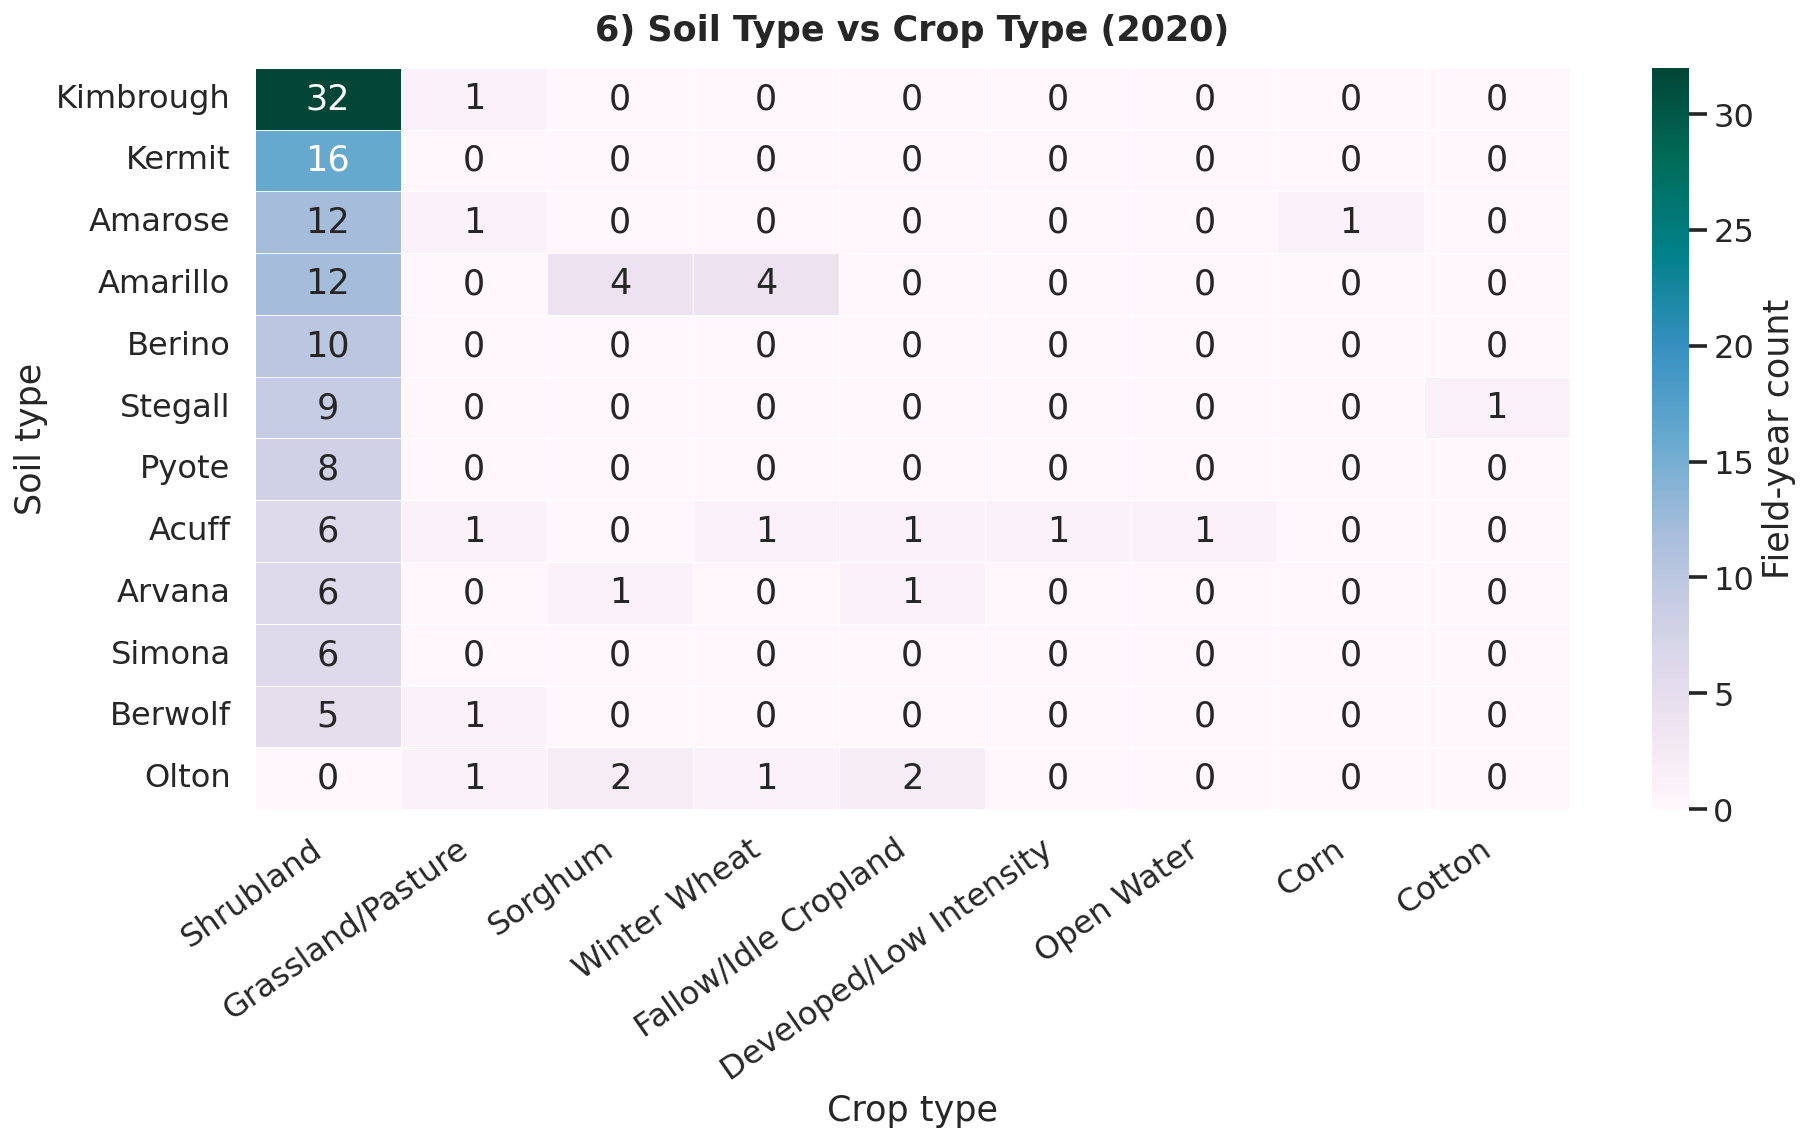

In [13]:
year_df = dashboard_df[dashboard_df["year"] == 2020].copy()
top_soils_2020 = year_df["soil_type"].value_counts().head(12).index
top_crops_2020 = year_df["crop_name"].value_counts().head(10).index

ct_2020 = pd.crosstab(
    year_df[year_df["soil_type"].isin(top_soils_2020)]["soil_type"],
    year_df[year_df["soil_type"].isin(top_soils_2020)]["crop_name"],
)
ct_2020 = ct_2020.reindex(columns=[c for c in top_crops_2020 if c in ct_2020.columns], fill_value=0)
ct_2020 = ct_2020.sort_values(by=ct_2020.columns.tolist(), ascending=False)

plt.figure(figsize=(14, 8.5))
ax = sns.heatmap(ct_2020, cmap="PuBuGn", annot=True, fmt="d", linewidths=0.35, cbar_kws={"label": "Field-year count"})
ax.set_title("6) Soil Type vs Crop Type (2020)", pad=14, weight="bold")
ax.set_xlabel("Crop type")
ax.set_ylabel("Soil type")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(DASHBOARD_ASSETS_DIR / "06_soil_type_vs_crop_type_2020.png", bbox_inches="tight")
plt.show()

**Interpretation - 2020 soil type vs crop type**

Compared with the 2010 matrix, this view highlights whether frequent soil-crop pairings stayed stable or shifted by 2020. Emphasis should be placed on persistent high-count cells.

/tmp/ipykernel_35483/983414871.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


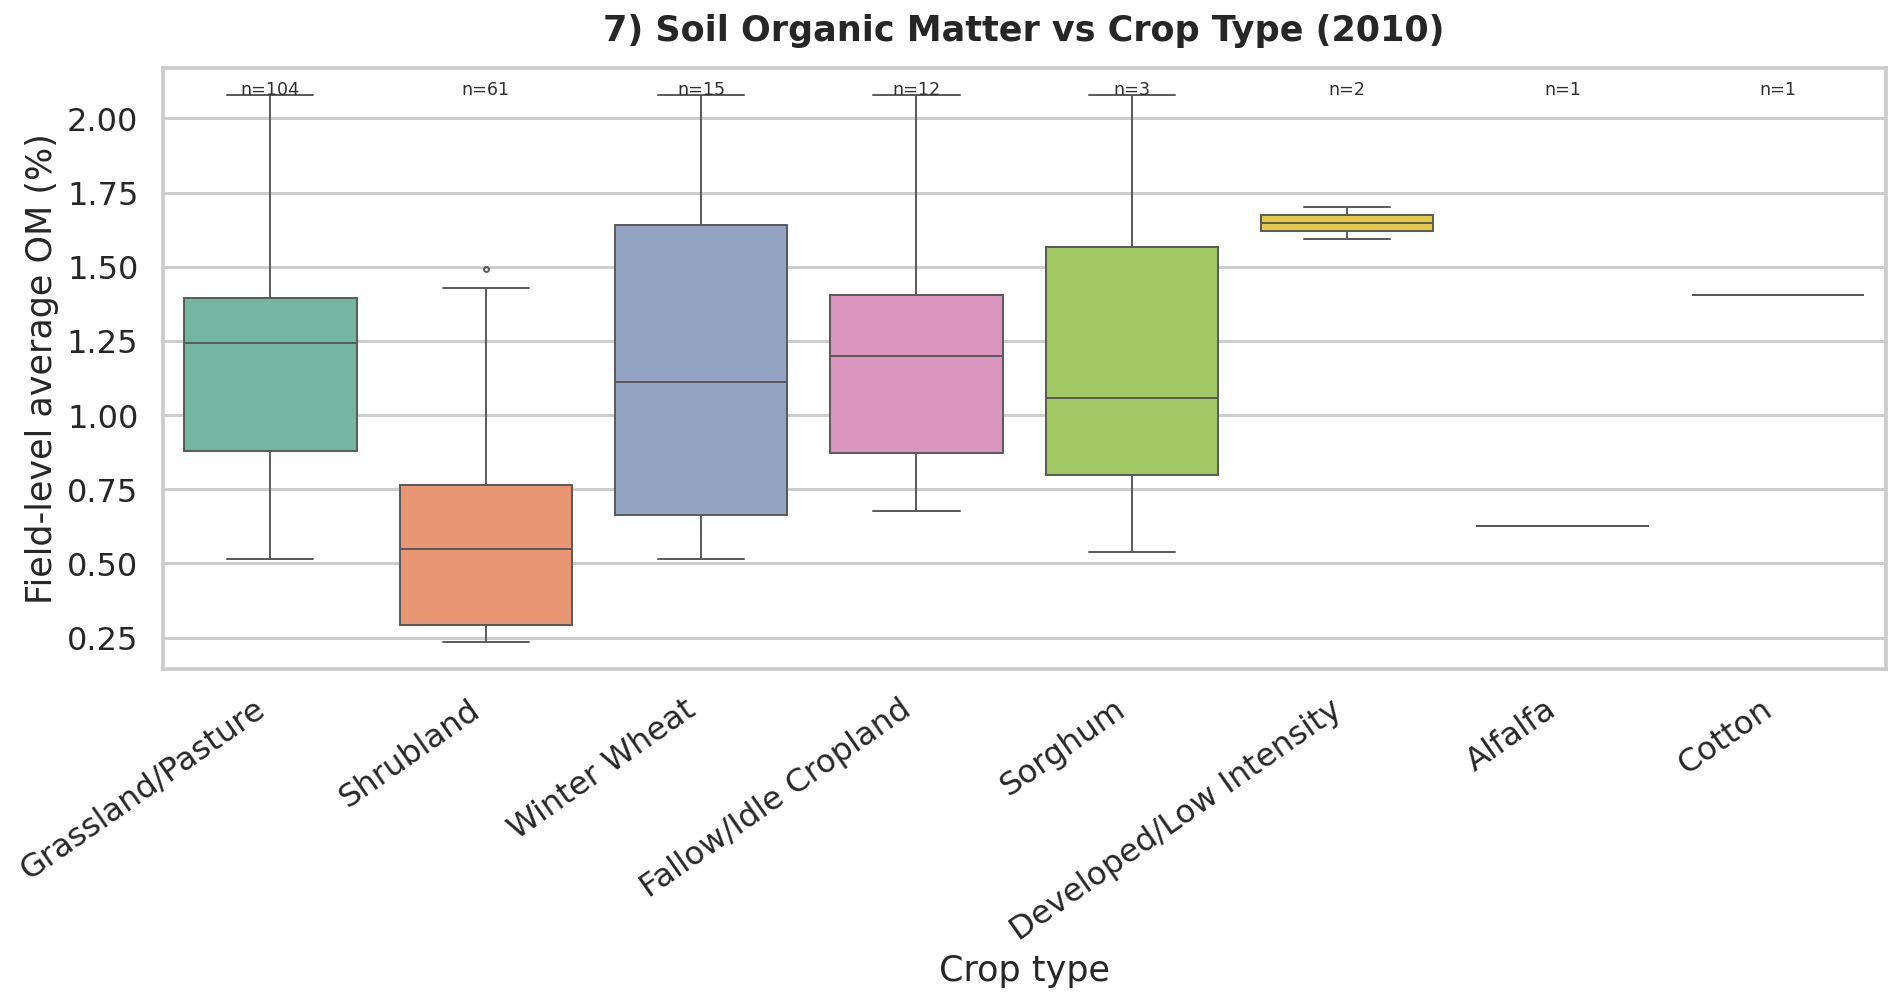

In [14]:
year_df = dashboard_df[dashboard_df["year"] == 2010].copy()
top_crops_2010 = year_df["crop_name"].value_counts().head(10).index
om_crop_2010 = year_df[year_df["crop_name"].isin(top_crops_2010)].copy()

plt.figure(figsize=(14, 7.5))
ax = sns.boxplot(
    data=om_crop_2010,
    x="crop_name",
    y="om_r_field_avg",
    order=om_crop_2010["crop_name"].value_counts().index,
    palette="Set2",
    fliersize=2.5,
)
ax.set_title("7) Soil Organic Matter vs Crop Type (2010)", pad=14, weight="bold")
ax.set_xlabel("Crop type")
ax.set_ylabel("Field-level average OM (%)")
plt.xticks(rotation=35, ha="right")
for i, crop in enumerate(om_crop_2010["crop_name"].value_counts().index):
    n_val = int((om_crop_2010["crop_name"] == crop).sum())
    ax.text(i, ax.get_ylim()[1] * 0.98, f"n={n_val}", ha="center", va="top", fontsize=9, color="#2f2f2f")
plt.tight_layout()
plt.savefig(DASHBOARD_ASSETS_DIR / "07_soil_organic_matter_vs_crop_type_2010.png", bbox_inches="tight")
plt.show()

**Interpretation - 2010 OM vs crop type**

Boxplots compare OM distributions by crop class in 2010. Median lines and interquartile ranges show where OM tends to be higher or lower, while `n=` labels indicate sample support for each crop.

/tmp/ipykernel_35483/3841821997.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


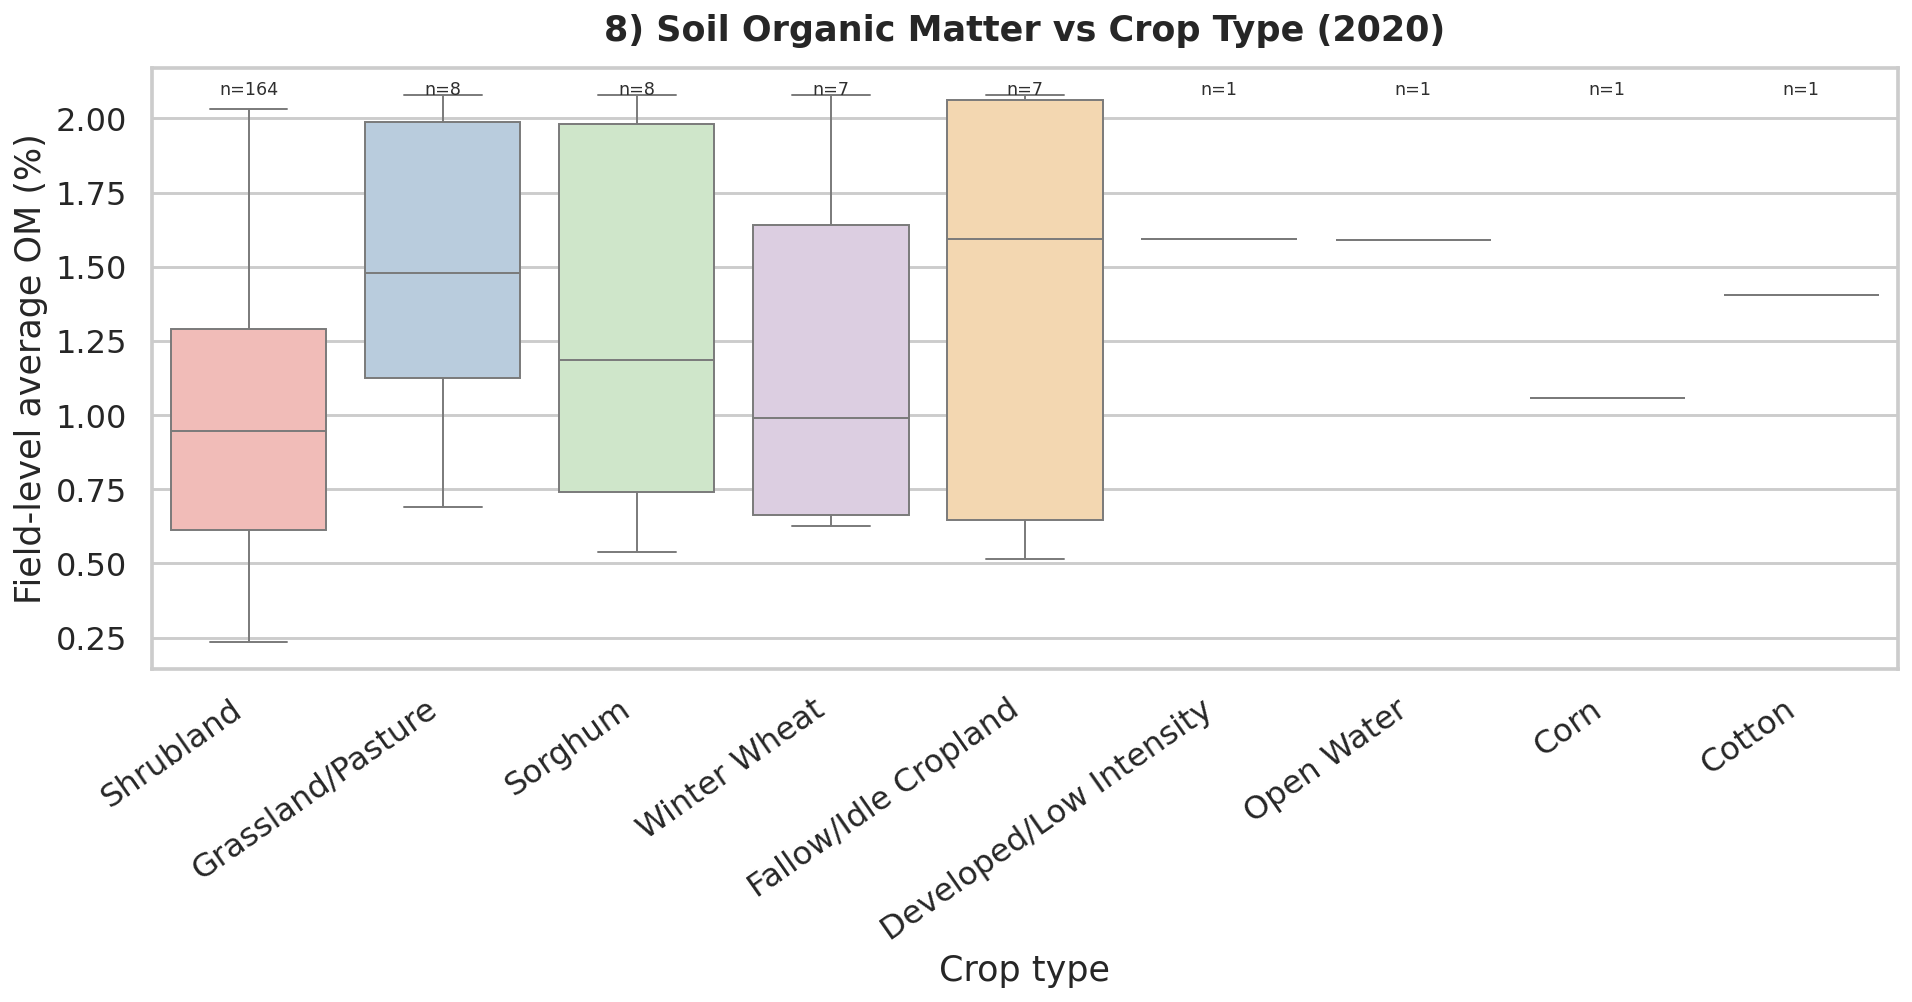

In [15]:
year_df = dashboard_df[dashboard_df["year"] == 2020].copy()
top_crops_2020 = year_df["crop_name"].value_counts().head(10).index
om_crop_2020 = year_df[year_df["crop_name"].isin(top_crops_2020)].copy()

plt.figure(figsize=(14, 7.5))
ax = sns.boxplot(
    data=om_crop_2020,
    x="crop_name",
    y="om_r_field_avg",
    order=om_crop_2020["crop_name"].value_counts().index,
    palette="Pastel1",
    fliersize=2.5,
)
ax.set_title("8) Soil Organic Matter vs Crop Type (2020)", pad=14, weight="bold")
ax.set_xlabel("Crop type")
ax.set_ylabel("Field-level average OM (%)")
plt.xticks(rotation=35, ha="right")
for i, crop in enumerate(om_crop_2020["crop_name"].value_counts().index):
    n_val = int((om_crop_2020["crop_name"] == crop).sum())
    ax.text(i, ax.get_ylim()[1] * 0.98, f"n={n_val}", ha="center", va="top", fontsize=9, color="#2f2f2f")
plt.tight_layout()
plt.savefig(DASHBOARD_ASSETS_DIR / "08_soil_organic_matter_vs_crop_type_2020.png", bbox_inches="tight")
plt.show()

**Interpretation - 2020 OM vs crop type**

This 2020 view can be compared directly to the 2010 boxplots to assess consistency or shifts in OM distributions by crop class. Differences should be interpreted alongside sample sizes and category prevalence.

In [16]:
dashboard_cards = [
    ("01_crop_total_estimated_area_2010.png", "1) Crop Total Estimated Area - 2010", "Estimated acreage by crop class for 2010 after exclusion filtering."),
    ("02_crop_total_estimated_area_2020.png", "2) Crop Total Estimated Area - 2020", "Estimated acreage by crop class for 2020 after exclusion filtering."),
    ("03_soil_organic_matter_distribution_2010.png", "3) Soil Organic Matter Distribution - 2010", "Field-level OM distribution among 2010 field records."),
    ("04_soil_organic_matter_distribution_2020.png", "4) Soil Organic Matter Distribution - 2020", "Field-level OM distribution among 2020 field records."),
    ("05_soil_type_vs_crop_type_2010.png", "5) Soil Type vs Crop Type - 2010", "Count heatmap of soil-crop combinations in 2010."),
    ("06_soil_type_vs_crop_type_2020.png", "6) Soil Type vs Crop Type - 2020", "Count heatmap of soil-crop combinations in 2020."),
    ("07_soil_organic_matter_vs_crop_type_2010.png", "7) Soil Organic Matter vs Crop Type - 2010", "OM boxplots by crop class with sample-size context."),
    ("08_soil_organic_matter_vs_crop_type_2020.png", "8) Soil Organic Matter vs Crop Type - 2020", "OM boxplots by crop class with sample-size context."),
]

cards_html = ""
for file_name, title, description in dashboard_cards:
    cards_html += f"""
    <section class='card'>
      <h2>{title}</h2>
      <p>{description}</p>
      <img src='dashboard_assets/{file_name}' alt='{title}' loading='lazy' />
    </section>
    """

dashboard_html = f"""<!doctype html>
<html lang='en'>
<head>
  <meta charset='utf-8' />
  <meta name='viewport' content='width=device-width, initial-scale=1' />
  <title>Assignment 03 EDA Dashboard</title>
  <style>
    :root {{
      --bg: #f5f7f2;
      --panel: #ffffff;
      --ink: #1f2a2e;
      --muted: #56646b;
      --accent: #1f7a8c;
      --line: #dbe3dd;
    }}
    * {{ box-sizing: border-box; }}
    body {{ margin: 0; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; background: var(--bg); color: var(--ink); }}
    .wrap {{ max-width: 1300px; margin: 0 auto; padding: 28px 18px 40px; }}
    header {{ background: linear-gradient(140deg, #145a69, #2c9a78); color: #fff; border-radius: 14px; padding: 24px; margin-bottom: 20px; }}
    header h1 {{ margin: 0 0 8px 0; font-size: 1.95rem; }}
    header p {{ margin: 4px 0; max-width: 900px; line-height: 1.45; }}
    .grid {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(360px, 1fr)); gap: 16px; }}
    .card {{ background: var(--panel); border: 1px solid var(--line); border-radius: 12px; padding: 14px; box-shadow: 0 1px 4px rgba(0, 0, 0, 0.05); }}
    .card h2 {{ margin: 0 0 8px 0; font-size: 1.06rem; }}
    .card p {{ margin: 0 0 10px 0; color: var(--muted); font-size: 0.94rem; line-height: 1.4; }}
    .card img {{ width: 100%; border-radius: 8px; border: 1px solid var(--line); background: #fff; }}
    footer {{ margin-top: 22px; color: var(--muted); font-size: 0.88rem; }}
    @media (max-width: 720px) {{
      header h1 {{ font-size: 1.45rem; }}
      .grid {{ grid-template-columns: 1fr; }}
    }}
  </style>
</head>
<body>
  <div class='wrap'>
    <header>
      <h1>Assignment 03 - Field EDA Dashboard</h1>
      <p>Year-specific agronomic visual analysis for 2010 and 2020 using field-level crop and soil records.</p>
      <p>Filters applied: removed <strong>Other Hay/Non Alfalfa</strong>, <strong>Code_236</strong>, and <strong>Developed/Medium Intensity</strong>.</p>
    </header>
    <main class='grid'>
      {cards_html}
    </main>
    <footer>Generated from notebook: notebooks/03_field_eda/assignment-03-eda.ipynb</footer>
  </div>
</body>
</html>
"""

dashboard_path = OUTPUT_DIR / "field_eda_dashboard.html"
dashboard_path.write_text(dashboard_html, encoding="utf-8")
print(f"Dashboard written: {dashboard_path}")

Dashboard written: /workspaces/EVTLR-Project/output/field_eda_dashboard.html
